# 암환자 유전체 데이터 EDA

- **목표**: 암환자 유전체 변이 정보(4,384개 유전자)를 기반으로 암종(SUBCLASS)을 분류
- **특징**: 대부분의 유전자 값이 WT(wild type, 정상)이며, 일부가 변이(mutation) 코드를 가짐

---

## 1. Import

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
import warnings
import platform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    # Linux: sudo apt install fonts-nanum 후 사용 가능
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR = '../../data/raw/'

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

sns.set_style("whitegrid")

font_path = "/System/Library/AssetsV2/com_apple_MobileAsset_Font8/7a0b5c0f3c1d41c4c52a33343496c9c65ad52c50.asset/AssetData/NanumGothic.ttc"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

## 2. 데이터 로드

In [9]:
train = pd.read_csv(DATA_DIR + 'train.csv')
test  = pd.read_csv(DATA_DIR + 'test.csv')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

Train shape : (6201, 4386)
Test  shape : (2546, 4385)


## 3. 기본 정보

In [10]:
gene_cols = [c for c in train.columns if c not in ['ID', 'SUBCLASS']]

print('=== 컬럼 구성 ===')
print(f'  ID 컬럼    : 1개')
print(f'  타겟 컬럼  : 1개  (SUBCLASS)')
print(f'  유전자 컬럼: {len(gene_cols)}개')

print('\n=== 메모리 사용량 ===')
mem = train.memory_usage(deep=True).sum() / 1024**2
print(f'  Train: {mem:.1f} MB')

print('\n=== 데이터 타입 ===')
print(train.dtypes.value_counts())

print('\n=== 샘플 미리보기 (첫 3행) ===')
display(train[['ID', 'SUBCLASS'] + gene_cols[:5]].head(3))

=== 컬럼 구성 ===
  ID 컬럼    : 1개
  타겟 컬럼  : 1개  (SUBCLASS)
  유전자 컬럼: 4384개

=== 메모리 사용량 ===
  Train: 260.3 MB

=== 데이터 타입 ===
str    4386
Name: count, dtype: int64

=== 샘플 미리보기 (첫 3행) ===


,ID,SUBCLASS,A2M,AAAS,AADAT,AARS1,ABAT
0,TRAIN_0000,KIPAN,WT,WT,WT,WT,WT
1,TRAIN_0001,SARC,WT,WT,WT,WT,WT
2,TRAIN_0002,SKCM,R895R,WT,WT,WT,WT


## 4. 결측치 분석

In [11]:
train_missing = train.isnull().sum()
test_missing  = test.isnull().sum()

print(f'Train 결측치 있는 컬럼 수: {(train_missing > 0).sum()}')
print(f'Test  결측치 있는 컬럼 수: {(test_missing > 0).sum()}')

if (train_missing > 0).sum() > 0:
    display(train_missing[train_missing > 0].sort_values(ascending=False))

Train 결측치 있는 컬럼 수: 0
Test  결측치 있는 컬럼 수: 25


## 5. 타겟 변수 분석 (암종 분포)

In [12]:
subclass_counts = train['SUBCLASS'].value_counts()
n_classes = len(subclass_counts)

print(f'암종 종류 수: {n_classes}개')
print(f'\n=== 암종별 샘플 수 ===')
display(pd.DataFrame({
    '샘플 수': subclass_counts,
    '비율(%)': (subclass_counts / len(train) * 100).round(2)
}))

암종 종류 수: 26개

=== 암종별 샘플 수 ===


,샘플 수,비율(%)
SUBCLASS,,
BRCA,786,12.68
KIPAN,515,8.31
GBMLGG,461,7.43
STES,379,6.11
KIRC,334,5.39
THCA,324,5.22
SKCM,276,4.45
PRAD,266,4.29
OV,253,4.08


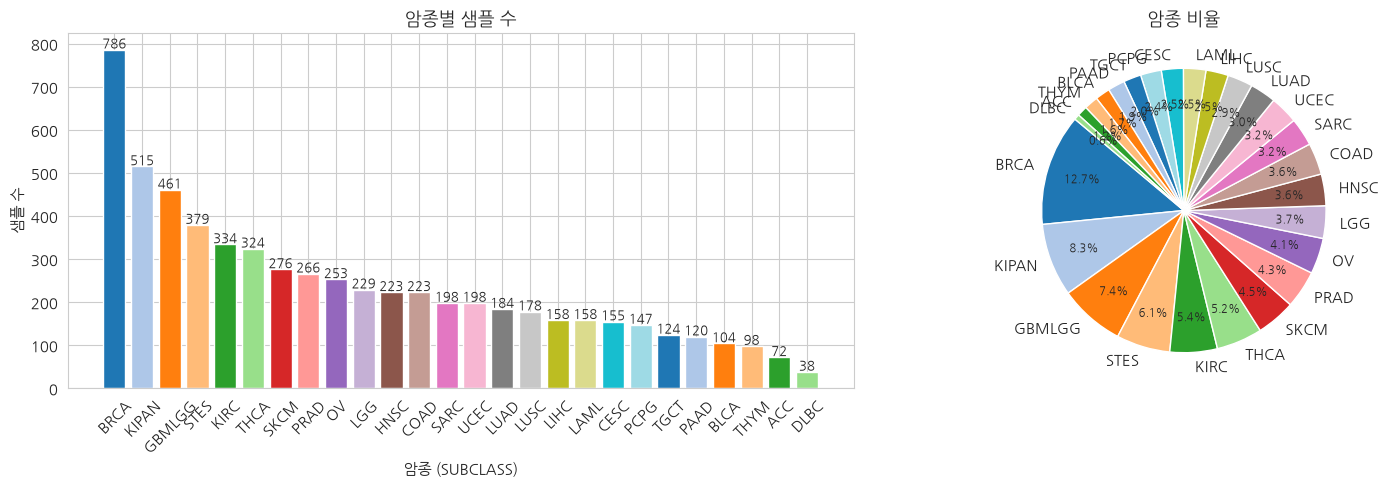

가장 많은 암종: BRCA (786개)
가장 적은 암종: DLBC (38개)
클래스 불균형 비율: 20.7x


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 막대 그래프
colors = sns.color_palette('tab20', n_classes)
axes[0].bar(subclass_counts.index, subclass_counts.values, color=colors)
axes[0].set_title('암종별 샘플 수', fontsize=13)
axes[0].set_xlabel('암종 (SUBCLASS)')
axes[0].set_ylabel('샘플 수')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(subclass_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# 파이 차트
wedges, texts, autotexts = axes[1].pie(
    subclass_counts.values,
    labels=subclass_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title('암종 비율', fontsize=13)

plt.tight_layout()
plt.show()

max_cls = subclass_counts.idxmax()
min_cls = subclass_counts.idxmin()
ratio = subclass_counts.max() / subclass_counts.min()
print(f'가장 많은 암종: {max_cls} ({subclass_counts.max()}개)')
print(f'가장 적은 암종: {min_cls} ({subclass_counts.min()}개)')
print(f'클래스 불균형 비율: {ratio:.1f}x')

## 6. 변이(Mutation) 희소성 분석

유전자 특성의 대부분 값이 `WT`(wild type, 정상)이고 일부만 변이 코드를 가짐

In [14]:
X = train[gene_cols]

# WT 비율
total_cells = X.shape[0] * X.shape[1]
wt_cells    = (X == 'WT').sum().sum()
mut_cells   = total_cells - wt_cells

print('=== 전체 유전자 행렬 희소성 ===')
print(f'  전체 셀 수     : {total_cells:,}')
print(f'  WT(정상) 수    : {wt_cells:,}  ({wt_cells/total_cells*100:.2f}%)')
print(f'  변이 발생 수   : {mut_cells:,}  ({mut_cells/total_cells*100:.2f}%)')

# 유전자별 변이율
gene_mut_rate = (X != 'WT').mean().sort_values(ascending=False)
print(f'\n=== 유전자별 변이율 분포 ===')
print(f'  변이 전혀 없는 유전자: {(gene_mut_rate == 0).sum()}개')
print(f'  변이율 > 1%인 유전자 : {(gene_mut_rate > 0.01).sum()}개')
print(f'  변이율 > 5%인 유전자 : {(gene_mut_rate > 0.05).sum()}개')
print(f'  변이율 > 10%인 유전자: {(gene_mut_rate > 0.10).sum()}개')

=== 전체 유전자 행렬 희소성 ===
  전체 셀 수     : 27,185,184
  WT(정상) 수    : 26,966,291  (99.19%)
  변이 발생 수   : 218,893  (0.81%)

=== 유전자별 변이율 분포 ===
  변이 전혀 없는 유전자: 154개
  변이율 > 1%인 유전자 : 1055개
  변이율 > 5%인 유전자 : 23개
  변이율 > 10%인 유전자: 4개


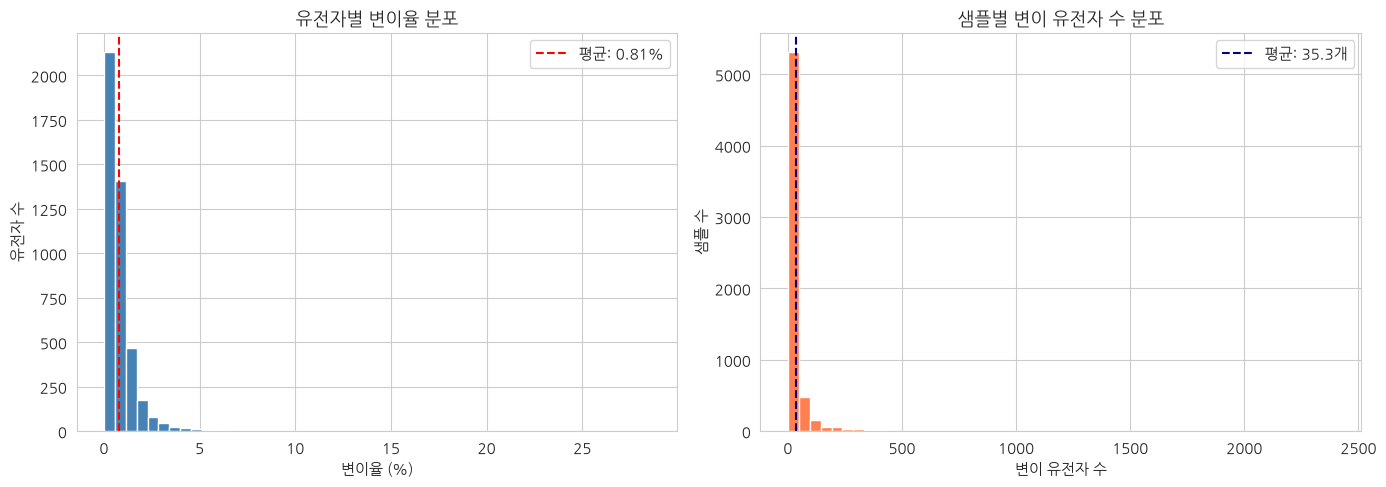

샘플당 평균 변이 유전자 수: 35.3개
샘플당 최대 변이 유전자 수: 2393개
샘플당 최소 변이 유전자 수: 0개


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 유전자별 변이율 분포
axes[0].hist(gene_mut_rate.values * 100, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('유전자별 변이율 분포', fontsize=13)
axes[0].set_xlabel('변이율 (%)')
axes[0].set_ylabel('유전자 수')
axes[0].axvline(gene_mut_rate.mean() * 100, color='red', linestyle='--', label=f'평균: {gene_mut_rate.mean()*100:.2f}%')
axes[0].legend()

# 샘플별 변이 수
sample_mut_count = (X != 'WT').sum(axis=1)
axes[1].hist(sample_mut_count.values, bins=50, color='coral', edgecolor='white')
axes[1].set_title('샘플별 변이 유전자 수 분포', fontsize=13)
axes[1].set_xlabel('변이 유전자 수')
axes[1].set_ylabel('샘플 수')
axes[1].axvline(sample_mut_count.mean(), color='navy', linestyle='--', label=f'평균: {sample_mut_count.mean():.1f}개')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'샘플당 평균 변이 유전자 수: {sample_mut_count.mean():.1f}개')
print(f'샘플당 최대 변이 유전자 수: {sample_mut_count.max()}개')
print(f'샘플당 최소 변이 유전자 수: {sample_mut_count.min()}개')

## 7. 변이 빈도 상위 유전자

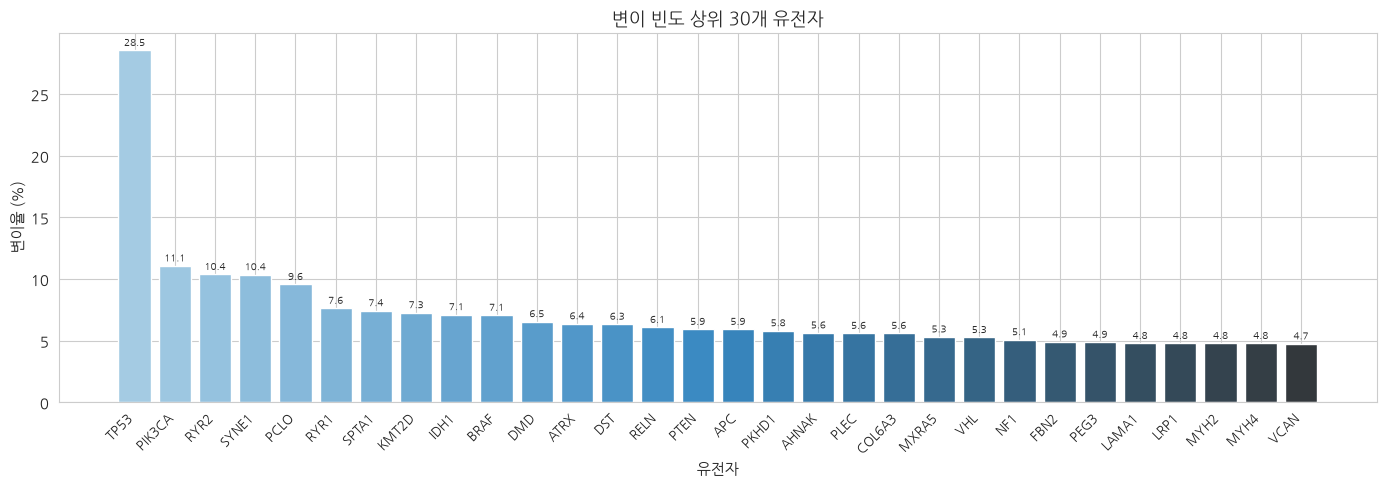

변이 빈도 상위 10개 유전자:


,유전자,변이율(%),변이 샘플 수
0,TP53,28.54,1770
1,PIK3CA,11.06,686
2,RYR2,10.37,643
3,SYNE1,10.35,642
4,PCLO,9.56,593
5,RYR1,7.63,473
6,SPTA1,7.43,461
7,KMT2D,7.27,451
8,IDH1,7.11,441
9,BRAF,7.06,438


In [16]:
top_n = 30
top_genes = gene_mut_rate.head(top_n)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(top_n), top_genes.values * 100, color=sns.color_palette('Blues_d', top_n))
ax.set_xticks(range(top_n))
ax.set_xticklabels(top_genes.index, rotation=45, ha='right', fontsize=9)
ax.set_title(f'변이 빈도 상위 {top_n}개 유전자', fontsize=13)
ax.set_xlabel('유전자')
ax.set_ylabel('변이율 (%)')
for bar, val in zip(bars, top_genes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val*100:.1f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

print('변이 빈도 상위 10개 유전자:')
display(pd.DataFrame({
    '유전자': top_genes.index[:10],
    '변이율(%)': (top_genes.values[:10] * 100).round(2),
    '변이 샘플 수': (top_genes.values[:10] * len(train)).astype(int)
}).reset_index(drop=True))

## 8. 암종별 변이 패턴 분석

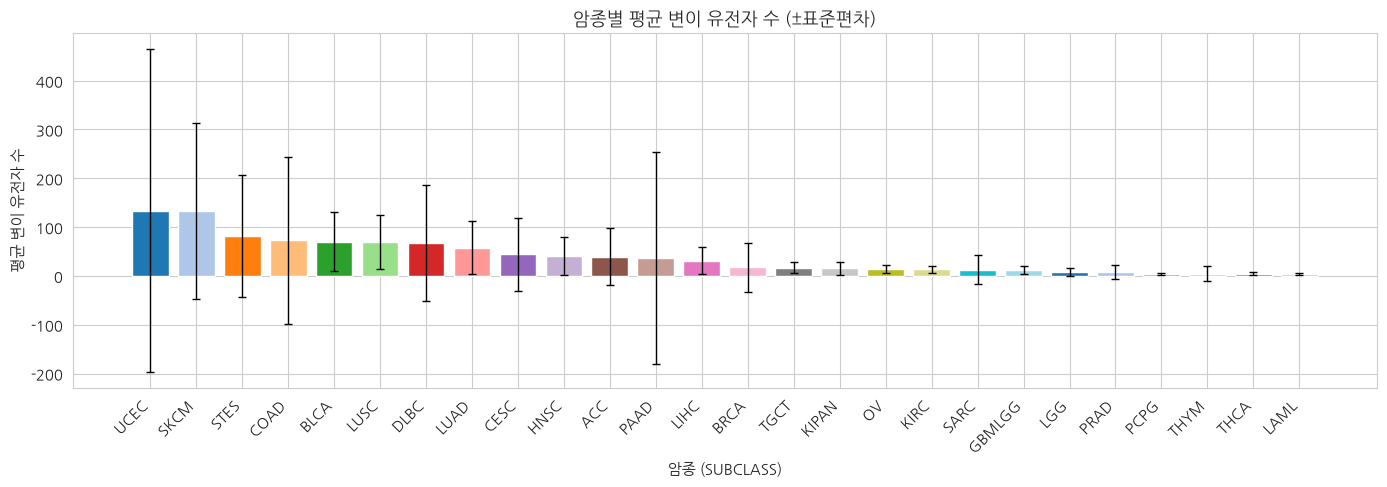

,평균,중앙값,표준편차
SUBCLASS,,,
UCEC,133.97,18.0,331.09
SKCM,132.53,85.5,179.83
STES,81.84,41.0,125.71
COAD,73.12,23.0,171.48
BLCA,70.49,54.0,60.52
LUSC,69.53,57.0,56.01
DLBC,67.42,30.0,119.22
LUAD,58.04,40.5,53.69
CESC,44.13,20.0,75.12


In [17]:
# 암종별 평균 변이 유전자 수
train_with_mut = train.copy()
train_with_mut['mutation_count'] = (train[gene_cols] != 'WT').sum(axis=1)

subclass_mut = train_with_mut.groupby('SUBCLASS')['mutation_count'].agg(['mean', 'median', 'std'])
subclass_mut.columns = ['평균', '중앙값', '표준편차']
subclass_mut = subclass_mut.sort_values('평균', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(subclass_mut))
ax.bar(x, subclass_mut['평균'], color=sns.color_palette('tab20', len(subclass_mut)))
ax.errorbar(x, subclass_mut['평균'], yerr=subclass_mut['표준편차'],
            fmt='none', color='black', capsize=3, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(subclass_mut.index, rotation=45, ha='right')
ax.set_title('암종별 평균 변이 유전자 수 (±표준편차)', fontsize=13)
ax.set_xlabel('암종 (SUBCLASS)')
ax.set_ylabel('평균 변이 유전자 수')
plt.tight_layout()
plt.show()

display(subclass_mut.round(2))

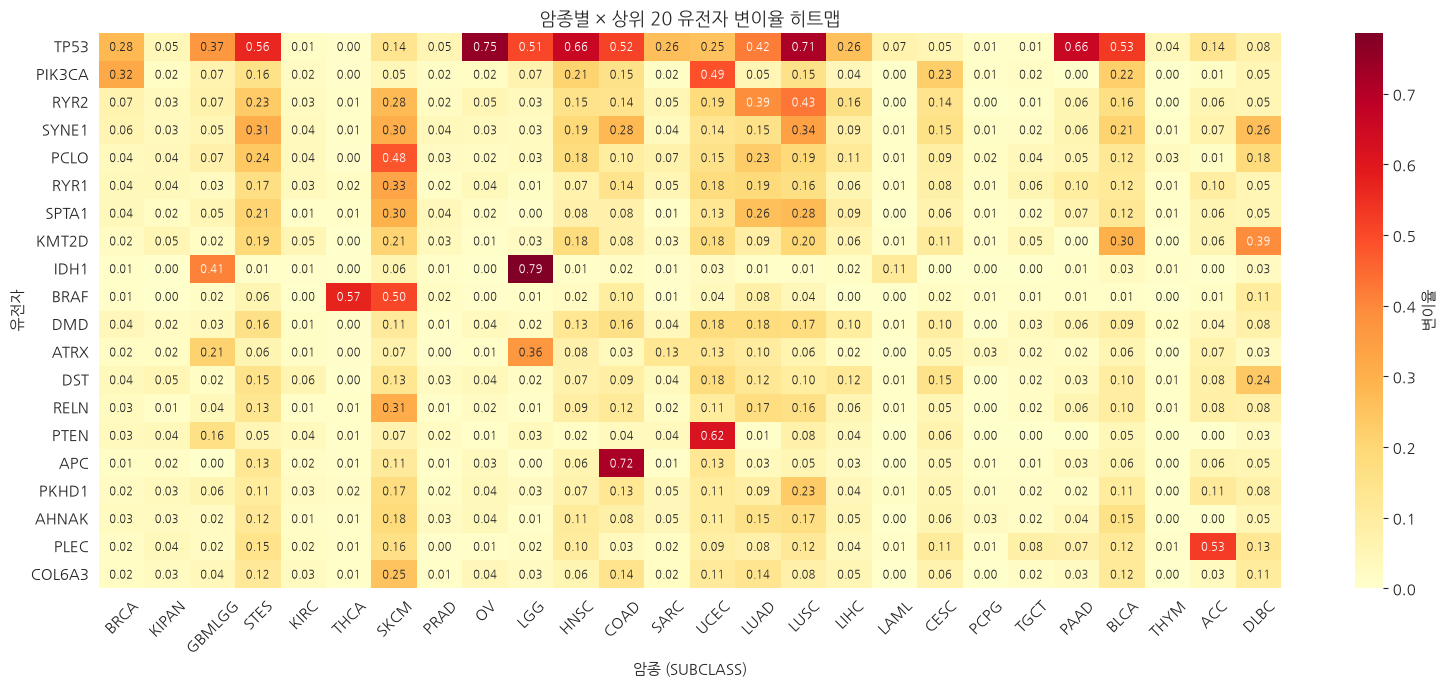

In [18]:
# 상위 20개 유전자 × 암종별 변이율 히트맵
top20_genes = gene_mut_rate.head(20).index.tolist()

heatmap_data = pd.DataFrame()
for subclass in train['SUBCLASS'].unique():
    subset = train[train['SUBCLASS'] == subclass][top20_genes]
    mut_rate = (subset != 'WT').mean()
    heatmap_data[subclass] = mut_rate

heatmap_data = heatmap_data[subclass_counts.index]  # 샘플 수 순서로

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': '변이율'},
    annot_kws={'size': 8}
)
ax.set_title('암종별 × 상위 20 유전자 변이율 히트맵', fontsize=13)
ax.set_xlabel('암종 (SUBCLASS)')
ax.set_ylabel('유전자')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 9. 암종 특이적 유전자 (암종별 고유 변이 유전자)

In [19]:
# 각 암종에서만 높은 변이율을 보이는 유전자 탐색
# 암종별 변이율 - 전체 평균 변이율
overall_mut_rate = (train[gene_cols] != 'WT').mean()

print('=== 암종별 특이적 변이 유전자 (상위 5개) ===')
specific_genes = {}
for subclass in subclass_counts.index:
    subset = train[train['SUBCLASS'] == subclass][gene_cols]
    subclass_rate = (subset != 'WT').mean()
    enrichment = subclass_rate - overall_mut_rate
    top5 = enrichment.sort_values(ascending=False).head(5)
    specific_genes[subclass] = top5
    print(f'\n[{subclass}]')
    for gene, enrich in top5.items():
        abs_rate = subclass_rate[gene]
        print(f'  {gene}: 변이율 {abs_rate*100:.1f}% (전체 대비 +{enrich*100:.1f}%p)')

=== 암종별 특이적 변이 유전자 (상위 5개) ===

[BRCA]
  PIK3CA: 변이율 31.8% (전체 대비 +20.7%p)
  CDH1: 변이율 9.3% (전체 대비 +6.8%p)
  GATA3: 변이율 7.4% (전체 대비 +5.3%p)
  MAP3K1: 변이율 7.1% (전체 대비 +4.8%p)
  RUNX1: 변이율 2.8% (전체 대비 +1.7%p)

[KIPAN]
  VHL: 변이율 29.9% (전체 대비 +24.6%p)
  PABPC1: 변이율 4.7% (전체 대비 +3.2%p)
  MET: 변이율 3.7% (전체 대비 +1.4%p)
  MAML2: 변이율 3.1% (전체 대비 +1.4%p)
  AQP7: 변이율 2.1% (전체 대비 +1.4%p)

[GBMLGG]
  IDH1: 변이율 41.0% (전체 대비 +33.9%p)
  ATRX: 변이율 21.5% (전체 대비 +15.1%p)
  EGFR: 변이율 14.5% (전체 대비 +10.7%p)
  PTEN: 변이율 16.3% (전체 대비 +10.4%p)
  TP53: 변이율 36.7% (전체 대비 +8.1%p)

[STES]
  TP53: 변이율 56.5% (전체 대비 +27.9%p)
  SYNE1: 변이율 30.6% (전체 대비 +20.3%p)
  PCLO: 변이율 24.0% (전체 대비 +14.4%p)
  SPTA1: 변이율 20.8% (전체 대비 +13.4%p)
  RYR2: 변이율 23.2% (전체 대비 +12.8%p)

[KIRC]
  VHL: 변이율 45.2% (전체 대비 +40.0%p)
  PABPC1: 변이율 4.8% (전체 대비 +3.4%p)
  MTOR: 변이율 5.7% (전체 대비 +2.1%p)
  AQP7: 변이율 2.4% (전체 대비 +1.7%p)
  HSPA8: 변이율 2.4% (전체 대비 +1.2%p)

[THCA]
  BRAF: 변이율 57.4% (전체 대비 +50.3%p)
  HRAS: 변이율 3.7% (전체 대비 +2.5%p)
  EIF1AX: 변이율 0.

## 10. 변이 종류 분석 (WT vs 변이 코드)

In [20]:
# 전체 변이 값 수집 (WT 제외)
all_mutations = []
for col in gene_cols:
    mutations = train[col][train[col] != 'WT'].values
    all_mutations.extend(mutations)

mut_counter = Counter(all_mutations)
total_unique = len(mut_counter)

print(f'전체 고유 변이 값 수: {total_unique:,}개')
print(f'\n가장 빈번한 변이 코드 TOP 20:')
mut_df = pd.DataFrame(mut_counter.most_common(20), columns=['변이 코드', '빈도'])
mut_df['비율(%)'] = (mut_df['빈도'] / len(all_mutations) * 100).round(3)
display(mut_df)

전체 고유 변이 값 수: 118,846개

가장 빈번한 변이 코드 TOP 20:


,변이 코드,빈도,비율(%)
0,R132H,349,0.159
1,V600E,305,0.139
2,E545K,135,0.062
3,H1047R,128,0.058
4,R273C,82,0.037
5,E542K,68,0.031
6,R175H,66,0.030
7,R273H,60,0.027
8,R132C,59,0.027
9,R248Q,49,0.022


=== 유전자별 고유 값 수 분포 ===
  고유 값 1개 (WT만): 154개 유전자
  고유 값 2~5개     : 61개 유전자
  고유 값 6~20개    : 925개 유전자
  고유 값 20개 초과 : 3244개 유전자
  최대 고유 값 수   : 664개 (TP53)


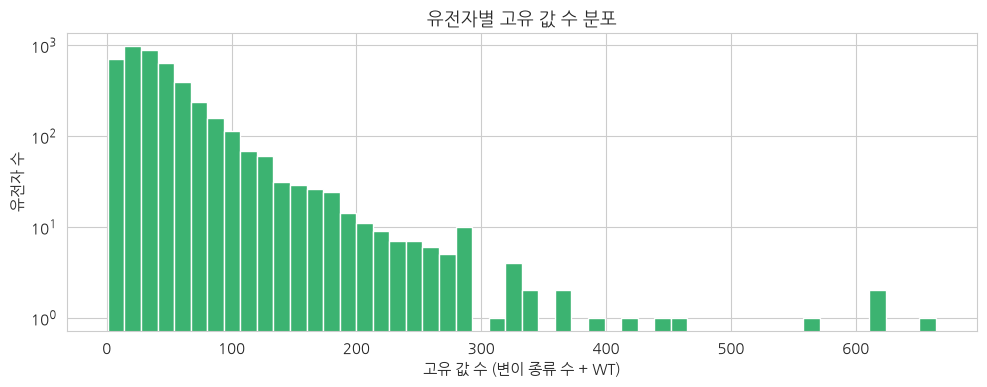

In [21]:
# 유전자별 고유 변이 값 수 분포
unique_per_gene = train[gene_cols].apply(lambda col: col.nunique())

print('=== 유전자별 고유 값 수 분포 ===')
print(f'  고유 값 1개 (WT만): {(unique_per_gene == 1).sum()}개 유전자')
print(f'  고유 값 2~5개     : {((unique_per_gene >= 2) & (unique_per_gene <= 5)).sum()}개 유전자')
print(f'  고유 값 6~20개    : {((unique_per_gene >= 6) & (unique_per_gene <= 20)).sum()}개 유전자')
print(f'  고유 값 20개 초과 : {(unique_per_gene > 20).sum()}개 유전자')
print(f'  최대 고유 값 수   : {unique_per_gene.max()}개 ({unique_per_gene.idxmax()})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(unique_per_gene.values, bins=50, color='mediumseagreen', edgecolor='white')
ax.set_title('유전자별 고유 값 수 분포', fontsize=13)
ax.set_xlabel('고유 값 수 (변이 종류 수 + WT)')
ax.set_ylabel('유전자 수')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 11. Train / Test 분포 비교

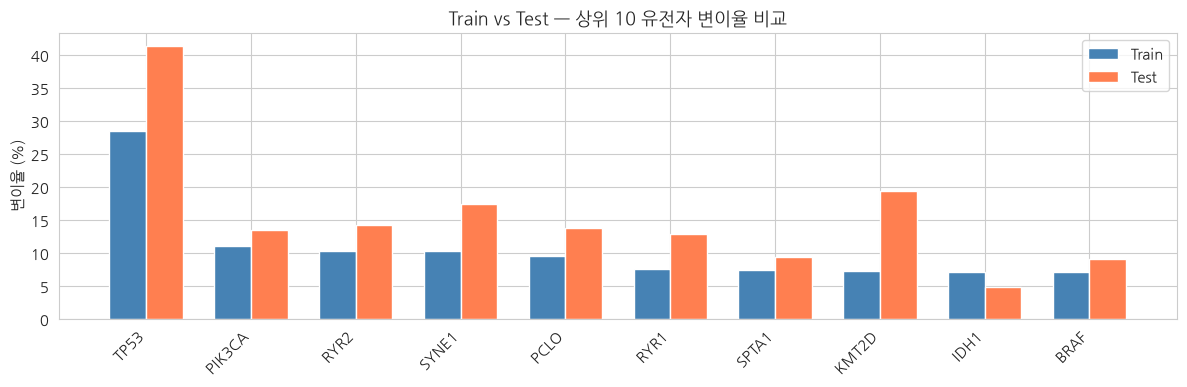

Train/Test 변이율 평균 절대 차이: 0.9879%p
가장 차이 큰 유전자: TCHH (25.39%p)


In [22]:
X_test = test[[c for c in gene_cols if c in test.columns]]

train_mut_rate = (train[gene_cols] != 'WT').mean()
test_mut_rate  = (X_test != 'WT').mean()

top10 = gene_mut_rate.head(10).index

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(top10))
w = 0.35
ax.bar(x - w/2, train_mut_rate[top10].values * 100, w, label='Train', color='steelblue')
ax.bar(x + w/2, test_mut_rate[top10].values * 100, w, label='Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(top10, rotation=45, ha='right')
ax.set_title('Train vs Test — 상위 10 유전자 변이율 비교', fontsize=13)
ax.set_ylabel('변이율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

# 분포 차이 (KL-divergence 수준의 간단 비교)
diff = (train_mut_rate - test_mut_rate).abs()
print(f'Train/Test 변이율 평균 절대 차이: {diff.mean()*100:.4f}%p')
print(f'가장 차이 큰 유전자: {diff.idxmax()} ({diff.max()*100:.2f}%p)')

## 12. EDA 요약

In [23]:
print('=' * 55)
print('                   EDA 요약')
print('=' * 55)
print(f'  Train 샘플 수       : {len(train):,}개')
print(f'  Test  샘플 수       : {len(test):,}개')
print(f'  유전자(feature) 수  : {len(gene_cols):,}개')
print(f'  암종 클래스 수      : {n_classes}개')
print(f'  결측치              : 없음')
print(f'  전체 변이율         : {mut_cells/total_cells*100:.2f}% (매우 희소)')
print(f'  샘플당 평균 변이 수 : {sample_mut_count.mean():.1f}개')
print(f'  클래스 불균형 비율  : {ratio:.1f}x')
print('=' * 55)
print()
print('[모델링 고려사항]')
print('  1. 피처가 범주형(WT / 변이코드) → 인코딩 필요')
print('     - OrdinalEncoder 또는 이진화(WT=0, 변이=1)')
print('  2. 극단적인 희소성 → 변이 여부(binary)만 사용하는 것도 유효')
print('  3. 클래스 불균형 → class_weight 또는 샘플링 전략 고려')
print('  4. 고차원(4384 피처) → 변이율 기반 피처 선택 권장')
print('  5. 암종별 특이 유전자가 존재 → 도메인 지식 활용 가능')

                   EDA 요약
  Train 샘플 수       : 6,201개
  Test  샘플 수       : 2,546개
  유전자(feature) 수  : 4,384개
  암종 클래스 수      : 26개
  결측치              : 없음
  전체 변이율         : 0.81% (매우 희소)
  샘플당 평균 변이 수 : 35.3개
  클래스 불균형 비율  : 20.7x

[모델링 고려사항]
  1. 피처가 범주형(WT / 변이코드) → 인코딩 필요
     - OrdinalEncoder 또는 이진화(WT=0, 변이=1)
  2. 극단적인 희소성 → 변이 여부(binary)만 사용하는 것도 유효
  3. 클래스 불균형 → class_weight 또는 샘플링 전략 고려
  4. 고차원(4384 피처) → 변이율 기반 피처 선택 권장
  5. 암종별 특이 유전자가 존재 → 도메인 지식 활용 가능


# 각 컬럼(유전자)별 변이(Variant) 추출 작업

In [25]:
import pandas as pd

print("1. train.csv 로드 중...")
df = pd.read_csv('../../data/raw/train.csv')

# 컬럼명 공백 제거
df.columns = [c.strip() for c in df.columns]

print("2. 변이 유전자(non-WT) 추출 중...")
gene_cols = [c for c in df.columns if c not in ['ID', 'SUBCLASS']]

records = []
for col in gene_cols:
    s = df[col]
    mask = (s != 'WT') & (s.notna()) & (s != '')
    if mask.any():
        sub_df = df.loc[mask, ['ID', 'SUBCLASS', col]]
        for _, row in sub_df.iterrows():
            records.append({
                'ID': row['ID'],
                'SUBCLASS': row['SUBCLASS'],
                'Gene': col,
                'Variant': str(row[col]).strip()
            })

extracted_df = pd.DataFrame(records)

print("3. CSV 파일 패키징 중...")
# 1) 기본 롱-포맷 변이 추출 CSV
extracted_df.to_csv('extracted_variants.csv', index=False)

# 2) 유전자(컬럼)별 요약 CSV
gene_summary = extracted_df.groupby('Gene').agg(
    Mutation_Count=('ID', 'count'),
    Unique_Variants=('Variant', lambda x: ', '.join(set(x))),
    Mutated_IDs=('ID', lambda x: ', '.join(x))
).reset_index()
gene_summary.to_csv('gene_variant_summary.csv', index=False)

# 3) 샘플(ID)별 요약 CSV
sample_summary = extracted_df.groupby(['ID', 'SUBCLASS']).agg(
    Mutated_Gene_Count=('Gene', 'count'),
    Mutated_Genes=('Gene', lambda x: ', '.join(x)),
    Gene_Variants=('Variant', lambda x: ', '.join(f"{g}:{v}" for g, v in zip(extracted_df.loc[x.index, 'Gene'], x)))
).reset_index()
sample_summary.to_csv('sample_variant_summary.csv', index=False)

print("✅ 모든 CSV 파일 생성이 완료되었습니다!")

1. train.csv 로드 중...
2. 변이 유전자(non-WT) 추출 중...
3. CSV 파일 패키징 중...
✅ 모든 CSV 파일 생성이 완료되었습니다!


# 각 SUBCLASS(26개 암종)별로 전용 시트(Sheet)를 생성

In [26]:
import pandas as pd

%pip install openpyxl

# 1. 정제된 변이 데이터 로드
df = pd.read_csv('extracted_variants.csv')

# 2. 엑셀 파일 생성 (openpyxl 엔진 활용)
output_excel = 'Subclass_Variants_Summary.xlsx'

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Subclass별로 정렬하여 각 시트로 생성
    for subclass in sorted(df['SUBCLASS'].unique()):
        sub_df = df[df['SUBCLASS'] == subclass]
        
        # 유전자(Gene) 기준으로 변이 수, 변이 종류, 환자 리스트 집계
        gene_table = sub_df.groupby('Gene').agg(
            Mutation_Count=('ID', 'count'),
            Unique_Variants=('Variant', lambda x: ', '.join(sorted(set(x)))),
            Patient_List=('ID', lambda x: ', '.join(x))
        ).reset_index().sort_values(by='Mutation_Count', ascending=False)
        
        # Subclass 이름의 시트로 저장
        gene_table.to_excel(writer, sheet_name=subclass, index=False)

print("✅ 성공적으로 암종별 시트 분리 엑셀 파일이 생성되었습니다!")


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ 성공적으로 암종별 시트 분리 엑셀 파일이 생성되었습니다!
